# Mega Star Distribution Centre - Inventory analysis

## 1. Introduction

In this project, we will be exploring the Mega Star Distribution Centre Dataset, a comprehensive simulation dataset focused on warehousing and logistics. With over 50,000 square meters of space and more than 60,000 distinct locations for products, this dataset provides a valuable opportunity to delve into inventory management on a large scale.

The dataset consists of four primary components:

1. Product List: Contains essential information about all the products stored within the distribution centre, such as names, descriptions, unique identifiers, and other attributes relevant to inventory management.

2. Warehouse Stocks: Offers a detailed inventory report, showcasing current stock levels of products and their respective locations within the facility. Analyzing this data helps optimize storage space and efficient inventory replenishment.

3. Receiving Records: Tracks receiving activities over five days, including incoming shipments, product quantities, origins, and responsible personnel. This data provides insights into the efficiency of the receiving process.

4. Picking Records: Documents the process of fulfilling customer orders during the same five-day period. It includes details on products picked, quantities, retrieval locations, and personnel involved, helping optimize order fulfillment and improve customer satisfaction.

Throughout this analysis project, we aim to gain practical insights and enhance our understanding of inventory management, making informed decisions to optimize processes and improve overall efficiency.


## 2. Inventory management

As the inventory analyst overseeing the Mega Star Distribution Centre, your daily tasks are integral to the facility's seamless operations. Among these responsibilities, four critical tasks take precedence, each with a specific purpose:

 1. Racks Count List: This task involves creating a comprehensive inventory of the racks within the distribution centre. An accurate count of available racks is vital for efficient storage space management and streamlined product organization.

 2. Consolidation List: The consolidation list is a key tool for optimizing storage efficiency. By identifying opportunities to combine or rearrange items, you can enhance accessibility and reduce wasted space.

 3. Checking List Following a Specific Product List: To maintain precise inventory records, you will be creating a checking list based on a specific product list. This helps ensure that the actual inventory matches the documented quantities, reducing discrepancies and potential stockouts.
 
 4. Empty Locations List: Keeping track of empty locations is essential for efficient inventory management. This list allows you to quickly identify available storage space for incoming products, minimizing delays and maximizing storage utilization.
 
 5. Visualization: Provides a visual representation of the inventory's spatial distribution within the facility. By identifying hot spots and cold spots, it plays a crucial role in optimizing storage space and improving inventory accessibility. The insights contribute to enhanced operational efficiency and streamlined inventory management.

Each of these undertakings plays a vital role in optimizing storage space, improving accessibility, and ensuring precise inventory records. Together, let's embark on a journey into the world of inventory management at the Mega Star Distribution Centre, where we aim to enhance operational efficiency and maximize productivity.

### 2.1. Racks Count List

In this first step, we will create the "Racks Count List" for the Mega Star Distribution Centre. By analyzing the dataset "warehouse_stocks.csv" using Pandas, we'll gain insights into the facility's rack inventory. Additionally, we will utilize the "dc_locations.csv" dataset, which contains information about all the locations within the warehouse.

In [1]:
import pandas as pd
import csv

df = pd.read_csv('/kaggle/input/mega-star-distribution-centre/warehouse_stocks.csv', low_memory=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57623 entries, 0 to 57622
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Product      57623 non-null  object
 1   Description  57623 non-null  object
 2   Category     57623 non-null  object
 3   Brand        57623 non-null  object
 4   Size         57623 non-null  object
 5   Function     57623 non-null  object
 6   Colour       57623 non-null  object
 7   Pallet       57623 non-null  object
 8   Quantity     57623 non-null  int64 
 9   Location     57623 non-null  object
dtypes: int64(1), object(9)
memory usage: 4.4+ MB


In [2]:
df

,Product,Description,Category,Brand,Size,Function,Colour,Pallet,Quantity,Location
0,NoGrA3ruGr,Notebook Graph A3 ruled Grey,Notebook,Graph,A3,ruled,Grey,48*10*5,2400,BS60E
1,LaYn1516Gr,"Laptop Ynos 15"" 16GB RAM Grey",Laptop,Ynos,"15""",16GB RAM,Grey,16*1*1,16,CG91G
2,PeRe12SoWh,Pencil Reldeats 12 Soluble White,Pencil,Reldeats,12,Soluble,White,48*10*5,2400,BX92B
3,TaTR15AuWh,Table TRAMA 1500 Auto Adjustable White,Table,TRAMA,1500,Auto Adjustable,White,8*1*1,8,CZ87H
4,AlOv178GGr,"All-in-one Ovonel 17"" 8GB RAM Grey",All-in-one,Ovonel,"17""",8GB RAM,Grey,16*1*1,16,CS62F
...,...,...,...,...,...,...,...,...,...,...
57618,SPAl24WaGr,SPen Aloyarc 24 Watercolour Grey,SPen,Aloyarc,24,Watercolour,Grey,48*10*5,111,AF65H
57619,LaRe148GSi,"Laptop Rezar 14"" 8GB RAM Silver",Laptop,Rezar,"14""",8GB RAM,Silver,16*1*1,13,DZ53F
57620,DrWE12SlGr,Drawer WENO 1200 Sliding Grey,Drawer,WENO,1200,Sliding,Grey,8*1*1,1,DK65B
57621,PeAl12HeBl,Pencil Aloyarc 12 Hexagonal Black,Pencil,Aloyarc,12,Hexagonal,Black,48*10*5,103,BY27C


In [3]:
df_locations = pd.read_csv('/kaggle/input/mega-star-distribution-centre/dc_locations.csv', low_memory=False)
df_locations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65856 entries, 0 to 65855
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Location  65856 non-null  object
dtypes: object(1)
memory usage: 514.6+ KB


To create the "Racks Count List" for the Mega Star Distribution Centre, we will employ the provided Python code. This code utilizes the Pandas library to process the "warehouse_stocks.csv" dataset and the "dc_locations.csv" dataset.

The first step involves finding the locations in the distribution centre based on specific prefixes using the find_locations() function. These prefixes are derived from the "dc_locations.csv" dataset, and the function returns a list of matching locations sorted by their hierarchical structure.

Next, the sort_locations() function processes the generated list of locations and organizes them in a structured manner. It groups the locations by prefix and level, calculates the count of racks for each prefix and level combination, and then sorts the data accordingly.

Finally, the sorted and organized "Racks Count List" is saved to a new CSV file named "sorted_result.csv."

In [4]:
import pandas as pd

def find_locations(csv_file, prefixes):
    with open(csv_file, 'r') as file:
        reader = csv.reader(file)
        locations = []
        for row in reader:
            if any(row[9].startswith(prefix) for prefix in prefixes):
                locations.append(row)

    locations.sort(key=lambda x: (x[1][:4], x[1][4] if len(x[1]) > 4 else '', x[1][5:] if len(x[1]) > 5 else ''))

    return locations

def sort_locations(result_csv_file):
    df = pd.read_csv(result_csv_file)
    prefixes = df['Location'].str[:2].unique()
    df['Prefix'] = df['Location'].str[:2]
    df['Level'] = df['Location'].str[2:].str.extract(r'(\D+)')
    df.sort_values(['Prefix', 'Level'], inplace=True)
    prefix_level_counts = df.groupby(['Prefix', 'Level']).size()
    df['Prefix Level Count'] = df.apply(lambda row: prefix_level_counts.get((row['Prefix'], row['Level']), 0), axis=1)

    return df


result_csv_file_path = '/kaggle/input/mega-star-distribution-centre/warehouse_stocks.csv'

dc_locations_file_path = '/kaggle/input/mega-star-distribution-centre/dc_locations.csv'
dc_locations_df = pd.read_csv(dc_locations_file_path)

dc_locations_df['Prefixes'] = dc_locations_df['Location'].str[:2]

prefixes = dc_locations_df['Prefixes'].unique().tolist()

locations = find_locations(result_csv_file_path, prefixes)

new_csv_file_path = '/kaggle/working/sorted_locations.csv'
df.to_csv(new_csv_file_path, index=False)

print(f"Sorted locations saved to {new_csv_file_path}.")

sorted_locations = sort_locations(new_csv_file_path)

sorted_result_file_path = '/kaggle/working/sorted_result.csv'
sorted_locations.to_csv(sorted_result_file_path, index=False)

print(f"Sorted result saved to {sorted_result_file_path}.")

Sorted locations saved to /kaggle/working/sorted_locations.csv.
Sorted result saved to /kaggle/working/sorted_result.csv.


In [5]:
sorted_result_df = pd.read_csv(sorted_result_file_path)
sorted_result_df

,Product,Description,Category,Brand,Size,Function,Colour,Pallet,Quantity,Location,Prefix,Level,Prefix Level Count
0,KeSu35MeBl,Keyboard Susa 350 Mechanical Black,Keyboard,Susa,350,Mechanical,Black,16*10*1,160,AF83A,AF,A,83
1,CaWE18DoWh,Cabinet WENO 1800 Door White,Cabinet,WENO,1800,Door,White,8*1*1,8,AF46A,AF,A,83
2,GaAELErPi,Gaming Chair AEKI L Ergonomic Pink,Gaming Chair,AEKI,L,Ergonomic,Pink,16*1*1,16,AF14A,AF,A,83
3,AlOv1532Wh,"All-in-one Ovonel 15"" 32GB RAM White",All-in-one,Ovonel,"15""",32GB RAM,White,16*1*1,16,AF29A,AF,A,83
4,TVEs42SFSi,"TV Esnesih 42"" SFHD Silver",TV,Esnesih,"42""",SFHD,Silver,8*1*1,8,AF69A,AF,A,83
...,...,...,...,...,...,...,...,...,...,...,...,...,...
57618,MoHc35WiNa,Mouse Hcetigol 350 Wireled Navi,Mouse,Hcetigol,350,Wireled,Navi,16*10*1,63,DZ08H,DZ,H,87
57619,CuWE18LoGr,Cupboard WENO 1800 Locker Grey,Cupboard,WENO,1800,Locker,Grey,8*1*1,2,DZ64H,DZ,H,87
57620,KePH35ErBl,Keyboard PH 350 Ergonomic Black,Keyboard,PH,350,Ergonomic,Black,16*10*1,136,DZ73H,DZ,H,87
57621,KeSu27ErNa,Keyboard Susa 270 Ergonomic Navi,Keyboard,Susa,270,Ergonomic,Navi,16*10*1,154,DZ25H,DZ,H,87


### 2.2. Consolidation List

In the dynamic environment of the Mega Star Distribution Centre, daily activities often result in the creation of numerous loose pallets. To ensure efficient space utilization and streamline operations, we must consolidate these loose pallets regularly. Consolidation involves combining and rearranging pallets, optimizing storage space, and minimizing wasted areas within the warehouse.

In this next step of our inventory analysis project, we will focus on creating the "Consolidation List." This critical list serves as a guide to identify opportunities for pallet consolidation and maximize storage efficiency.

We will identify loose pallets that can be consolidated based on similar product types, sizes, or locations. Through this consolidation process, we aim to reduce clutter and improve accessibility to products, ultimately enhancing the distribution centre's operational efficiency.

In [6]:
import pandas as pd
import numpy as np
import csv

def extract_count(packsize):
    parts = packsize.split('*')
    count = np.prod([int(part) for part in parts])
    return count

df = pd.read_csv('/kaggle/input/mega-star-distribution-centre/warehouse_stocks.csv', low_memory=False)

new_df = df.copy()

new_df['Quantity'] = new_df['Quantity'].astype(int)

new_df['Pallet'] = new_df['Pallet'].fillna('0*0*0')

new_df['Count'] = new_df['Pallet'].apply(extract_count)
new_df['Pallet Type'] = np.where(new_df['Quantity'] >= new_df['Count'], 'Full', 'Loose')

new_df.loc[new_df['Count'] == 0, 'Pallet Type'] = np.nan

new_df.to_csv('/kaggle/working/warehouse_stocks_filtered.csv', index=False)

df1 = new_df[new_df['Quantity'] <= 0.2 * new_df['Count']]

df2 = new_df[(new_df['Quantity'] > 0.2 * new_df['Count']) & (new_df['Quantity'] < 0.6 * new_df['Count'])]

df3 = df1[['Product', 'Description', 'Category', 'Brand', 'Size', 'Function', 'Pallet', 'Quantity', 'Location']].copy()

df3['New location'] = df3['Product'].map(df2.drop_duplicates('Product').set_index('Product')['Location'])

df3 = df3.dropna(subset=['New location'])

output_file = '/kaggle/working/consolidation_list.csv'
df3.to_csv(output_file, index=False)

print("Consolidation list is saved to:", output_file)

Consolidation list is saved to: /kaggle/working/consolidation_list.csv


In [7]:
new_df

,Product,Description,Category,Brand,Size,Function,Colour,Pallet,Quantity,Location,Count,Pallet Type
0,NoGrA3ruGr,Notebook Graph A3 ruled Grey,Notebook,Graph,A3,ruled,Grey,48*10*5,2400,BS60E,2400,Full
1,LaYn1516Gr,"Laptop Ynos 15"" 16GB RAM Grey",Laptop,Ynos,"15""",16GB RAM,Grey,16*1*1,16,CG91G,16,Full
2,PeRe12SoWh,Pencil Reldeats 12 Soluble White,Pencil,Reldeats,12,Soluble,White,48*10*5,2400,BX92B,2400,Full
3,TaTR15AuWh,Table TRAMA 1500 Auto Adjustable White,Table,TRAMA,1500,Auto Adjustable,White,8*1*1,8,CZ87H,8,Full
4,AlOv178GGr,"All-in-one Ovonel 17"" 8GB RAM Grey",All-in-one,Ovonel,"17""",8GB RAM,Grey,16*1*1,16,CS62F,16,Full
...,...,...,...,...,...,...,...,...,...,...,...,...
57618,SPAl24WaGr,SPen Aloyarc 24 Watercolour Grey,SPen,Aloyarc,24,Watercolour,Grey,48*10*5,111,AF65H,2400,Loose
57619,LaRe148GSi,"Laptop Rezar 14"" 8GB RAM Silver",Laptop,Rezar,"14""",8GB RAM,Silver,16*1*1,13,DZ53F,16,Loose
57620,DrWE12SlGr,Drawer WENO 1200 Sliding Grey,Drawer,WENO,1200,Sliding,Grey,8*1*1,1,DK65B,8,Loose
57621,PeAl12HeBl,Pencil Aloyarc 12 Hexagonal Black,Pencil,Aloyarc,12,Hexagonal,Black,48*10*5,103,BY27C,2400,Loose


The consolidation list contains information about low-quantity items and their corresponding new locations:

In [8]:
df3

,Product,Description,Category,Brand,Size,Function,Pallet,Quantity,Location,New location
31281,LaYn1516Gr,"Laptop Ynos 15"" 16GB RAM Grey",Laptop,Ynos,"15""",16GB RAM,16*1*1,2,DS26D,BV30A
31282,PeRe12SoWh,Pencil Reldeats 12 Soluble White,Pencil,Reldeats,12,Soluble,48*10*5,399,DI42H,DQ04C
31295,AlSu1732Bl,"All-in-one Susa 17"" 32GB RAM Black",All-in-one,Susa,"17""",32GB RAM,16*1*1,1,CN88D,BI93G
31306,PrNoA3AlWh,Printer Nospe A3 All-in-one White,Printer,Nospe,A3,All-in-one,16*1*1,1,DT07A,BM92G
31307,TVYn32SFSi,"TV Ynos 32"" SFHD Silver",TV,Ynos,"32""",SFHD,8*1*1,1,CT34B,DM69C
...,...,...,...,...,...,...,...,...,...,...
57588,GaOGMErBl,Gaming Chair OGAP M Ergonomic Black,Gaming Chair,OGAP,M,Ergonomic,16*1*1,1,BT88C,AL74B
57592,PeAl12HeWh,Pencil Aloyarc 12 Hexagonal White,Pencil,Aloyarc,12,Hexagonal,48*10*5,354,CP90D,BW89B
57617,MoHc27MeWh,Mouse Hcetigol 270 Mechanical White,Mouse,Hcetigol,270,Mechanical,16*10*1,6,CV23D,DY43E
57618,SPAl24WaGr,SPen Aloyarc 24 Watercolour Grey,SPen,Aloyarc,24,Watercolour,48*10*5,111,AF65H,BR06E


### 2.3. Checking list by product

Managing a warehouse with a large inventory can be a challenging task, and it is essential to keep track of specific products regularly. To simplify this process, I have developed a Python script that generates a checking list by product. By utilizing two CSV files – 'warehouse_stocks.csv' containing the complete inventory and 'list_to_check.csv' with the products to verify – the script generates a sorted checking list with essential details like product names, descriptions, pallet information, quantities, and locations. This automated approach streamlines warehouse operations, reduces errors, and ensures efficient stock verification, enabling better inventory control and meeting customer demands effectively. The final checking list is easily exportable to a CSV file, 'checking_sheet.csv,' for practical use and distribution.

In [9]:
import pandas as pd

df = pd.read_csv('/kaggle/input/mega-star-distribution-centre/warehouse_stocks.csv', low_memory=False)
df.info()

df2 = pd.read_csv('/kaggle/input/mega-star-distribution-centre/list_to_check.csv')
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57623 entries, 0 to 57622
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Product      57623 non-null  object
 1   Description  57623 non-null  object
 2   Category     57623 non-null  object
 3   Brand        57623 non-null  object
 4   Size         57623 non-null  object
 5   Function     57623 non-null  object
 6   Colour       57623 non-null  object
 7   Pallet       57623 non-null  object
 8   Quantity     57623 non-null  int64 
 9   Location     57623 non-null  object
dtypes: int64(1), object(9)
memory usage: 4.4+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Product  200 non-null    object
dtypes: object(1)
memory usage: 1.7+ KB


In [10]:
product_list = df2['Product'].tolist()

filtered_df = df[df['Product'].isin(product_list)]

filtered_df = filtered_df[['Product', 'Description', 'Pallet', 'Quantity', 'Location']]

filtered_df = filtered_df.sort_values(by='Product')

filtered_df.to_csv('/kaggle/working/checking_sheet.csv', index=False)

print('Checking list is saved')

filtered_df

Checking list is saved


,Product,Description,Pallet,Quantity,Location
348,AlOv148GGr,"All-in-one Ovonel 14"" 8GB RAM Grey",16*1*1,16,BP53B
19116,AlOv148GGr,"All-in-one Ovonel 14"" 8GB RAM Grey",16*1*1,16,AN52B
19542,AlOv148GGr,"All-in-one Ovonel 14"" 8GB RAM Grey",16*1*1,16,CF68D
28926,AlOv148GGr,"All-in-one Ovonel 14"" 8GB RAM Grey",16*1*1,16,CJ43B
25798,AlOv148GGr,"All-in-one Ovonel 14"" 8GB RAM Grey",16*1*1,16,CP85B
...,...,...,...,...,...
34836,TaTR18WoSi,Table TRAMA 1800 Workstation Silver,8*1*1,4,BY07D
27759,TaTR18WoSi,Table TRAMK 1800 Workstation Silver,8*1*1,8,BM49F
30887,TaTR18WoSi,Table TRAMK 1800 Workstation Silver,8*1*1,8,BK28E
31955,TaTR18WoSi,Table TRAMA 1800 Workstation Silver,8*1*1,3,BM65A


The provided Python script above aims to create daily checking lists for warehouse inventory, considering that the checking list can be too long to complete in a single day. To tackle this, the script below splits the list of products to check into manageable batches of 10 products each day. Inputs the date for which we want to generate the checking list:

In [11]:
product_list = df2['Product'].tolist()

batch_size = 10

num_batches = len(product_list) // batch_size

date = 3

'''date = input("Enter the date: ")'''

result_df = pd.DataFrame()

for batch in range(num_batches + 1):
    start_idx = batch * batch_size
    end_idx = (batch + 1) * batch_size

    batch_products = product_list[start_idx:end_idx]

    filtered_df = df[df['Product'].isin(batch_products)]

    filtered_df = filtered_df[['Product', 'Description', 'Pallet', 'Quantity', 'Location']]

    result_df = pd.concat([result_df, filtered_df], ignore_index=True)

    if len(result_df) >= batch_size:
        break

result_df = result_df.sort_values(by='Product')

result_df.to_csv(f'/kaggle/working/checking_day_{date}.csv', index=False)

print(f'Checking sheet for day {date} is saved')

Checking sheet for day 3 is saved


In [12]:
result_df

,Product,Description,Pallet,Quantity,Location
0,AlOv148GGr,"All-in-one Ovonel 14"" 8GB RAM Grey",16*1*1,16,BP53B
145,AlOv148GGr,"All-in-one Ovonel 14"" 8GB RAM Grey",16*1*1,14,AF01F
40,AlOv148GGr,"All-in-one Ovonel 14"" 8GB RAM Grey",16*1*1,16,CQ33B
42,AlOv148GGr,"All-in-one Ovonel 14"" 8GB RAM Grey",16*1*1,16,DK45C
90,AlOv148GGr,"All-in-one Ovonel 14"" 8GB RAM Grey",16*1*1,16,BQ31B
...,...,...,...,...,...
169,TaCI18WoBl,Table CITSATNAF 1800 Workstation Black,8*1*1,1,DU06A
164,TaCI18WoBl,Table CITSATNAF 1800 Workstation Black,8*1*1,6,BG37A
64,TaCI18WoBl,Table CITSATNAF 1800 Workstation Black,8*1*1,8,CS92G
146,TaCI18WoBl,Table CITSATNAF 1800 Workstation Black,8*1*1,6,AM86B


### 2.4. Empty location list

To enhance inventory control and identify discrepancies, I have developed a Python script that creates an Empty Location List. This list contains all the empty locations within the warehouse, allowing staff to double-check for any misplaced stocks or incorrect quantities. This list serves as a foundation for maintaining an organized warehouse layout and ensuring accurate inventory records. Detecting any discrepancies and adjusting the system accordingly enhances efficiency and reliability, delivering prompt and accurate service to customers. The Empty Location List streamlines inventory control, promoting an organized and efficient warehouse operation:

In [13]:
import pandas as pd

df = pd.read_csv('/kaggle/input/mega-star-distribution-centre/warehouse_stocks.csv', low_memory=False)
df['Location'] = df['Location'].str.strip()

occupied_locations = set(df['Location'])

rack_locations_df = pd.read_csv('/kaggle/input/mega-star-distribution-centre/dc_locations.csv')
rack_locations_df['Location'] = rack_locations_df['Location'].str.strip()

empty_locations_df = rack_locations_df[~rack_locations_df['Location'].isin(occupied_locations)]

csv_file = '/kaggle/working/empty_locations.csv'
empty_locations_df.to_csv(csv_file, index=False)

print(f"The list of empty locations has been saved to {csv_file}.")

empty_locations_df

The list of empty locations has been saved to /kaggle/working/empty_locations.csv.


,Location
0,AF01A
1,AF01B
31,AF04H
35,AF05D
42,AF06C
...,...
65801,DZ92B
65814,DZ93G
65831,DZ95H
65834,DZ96C


## 3. Visualization

### 3.1. Stock Distribution Heatmap

The script generates a Heatmap visualization to illustrate the distribution of stock within a warehouse. By leveraging data from 'warehouse_stocks.csv' and 'rack_locations.csv' files, we analyze the allocation of products across different zones and rack numbers. The Heatmap provides an insightful overview, helping warehouse managers identify areas with high or low stock quantities efficiently.\
This graphical representation assists in decision-making, optimizing storage space, and streamlining inventory management. The Heatmap helps warehouse staff pinpoint areas with low stock levels, facilitating prompt restocking and avoiding overstocking issues.

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


The split_warehouse_stocks.csv has been saved


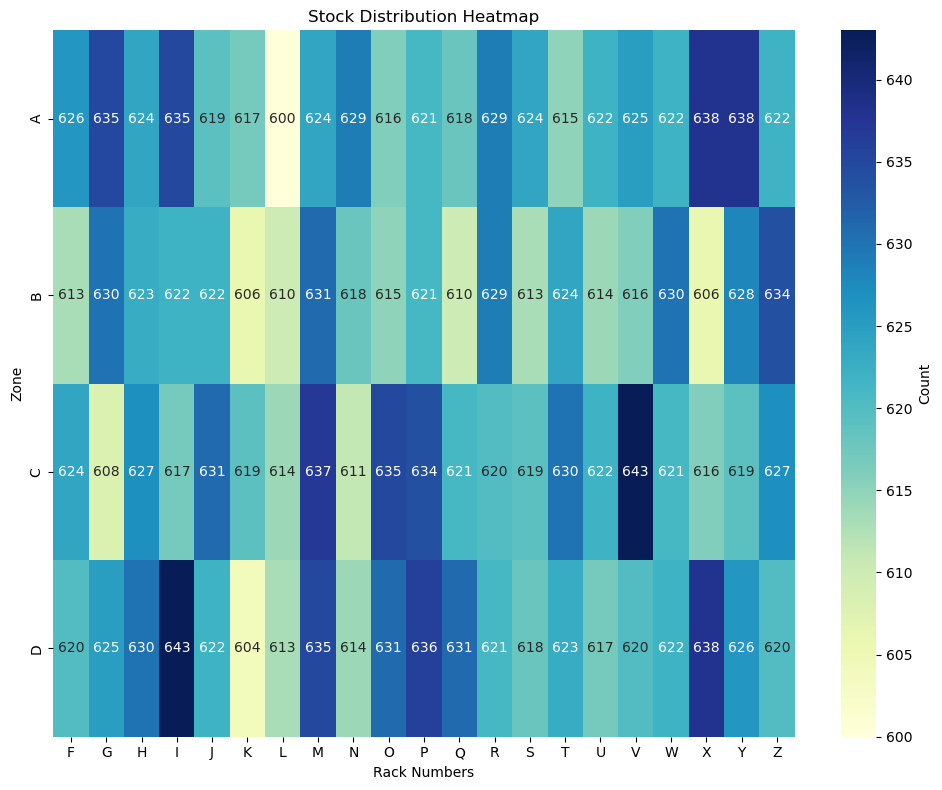

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/mega-star-distribution-centre/warehouse_stocks.csv', usecols=['Product', 'Description', 'Pallet', 'Quantity', 'Location'], low_memory=False)

df[['Zone', 'Rack_numbers', 'Location_numbers', 'Levels']] = df['Location'].str.extract(r'([A-Z])([A-Z])(\d{2})([A-H])')

df.drop('Location', axis=1, inplace=True)

df = df[['Product', 'Description', 'Pallet', 'Quantity', 'Zone', 'Rack_numbers', 'Location_numbers', 'Levels']]

df.to_csv('/kaggle/working/split_warehouse_stocks.csv', index=False)

print(f"The split_warehouse_stocks.csv has been saved")

df = pd.read_csv('/kaggle/working/split_warehouse_stocks.csv')

rack_locations_df = pd.read_csv('/kaggle/input/mega-star-distribution-centre/dc_locations.csv')

rack_locations_df[['Zone', 'Rack_numbers', 'Location_numbers', 'Levels']] = rack_locations_df['Location'].str.extract(r'([A-Z])([A-Z])(\d{2})([A-H])')

rack_locations_df['Location_numbers'] = rack_locations_df['Location_numbers'].astype(str)
df['Location_numbers'] = df['Location_numbers'].astype(str)

rack_stock = rack_locations_df.merge(df, how='left', on=['Zone', 'Rack_numbers', 'Location_numbers', 'Levels'])

grouped_stock = rack_stock.groupby(['Zone', 'Rack_numbers']).agg({'Product': lambda x: x.notnull().sum()}).reset_index()

heatmap_data = grouped_stock.pivot(index='Zone', columns='Rack_numbers', values='Product')

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='.0f', cbar_kws={'label': 'Count'})
plt.title('Stock Distribution Heatmap')
plt.xlabel('Rack Numbers')
plt.ylabel('Zone')
plt.tight_layout()
plt.show()

### 3.2. Activity Chart

The activity chart presented here showcases various visualizations and analyses related to the picking and receiving activities in a distribution center. The data has been collected over a span of five days from multiple CSV files. The main objective is to provide insights into the picking and receiving operations, including the performance of staff, the movement of pallets, and the trending products.\
\
The first section of the activity chart focuses on the picking process. It begins by loading the data from 'picking_1.csv' and processing it to extract essential information such as zones, rack numbers, location numbers, and levels. The resulting dataset is saved as 'split_picking_1.csv'. A heatmap is then generated to visualize the distribution of picking tasks across different zones and rack numbers. This heatmap provides a quick overview of the busiest areas in the warehouse during the five days.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9056 entries, 0 to 9055
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Product      9056 non-null   object
 1   Description  9056 non-null   object
 2   Category     9056 non-null   object
 3   Brand        9056 non-null   object
 4   Size         9056 non-null   object
 5   Function     9056 non-null   object
 6   Colour       9056 non-null   object
 7   Pallet       9056 non-null   object
 8   Quantity     9056 non-null   int64 
 9   Location     9056 non-null   object
 10  Staff        9056 non-null   object
 11  To           9056 non-null   object
 12  Customer     9056 non-null   int64 
 13  Task         9056 non-null   object
dtypes: int64(2), object(12)
memory usage: 990.6+ KB
The split_picking_1.csv has been saved


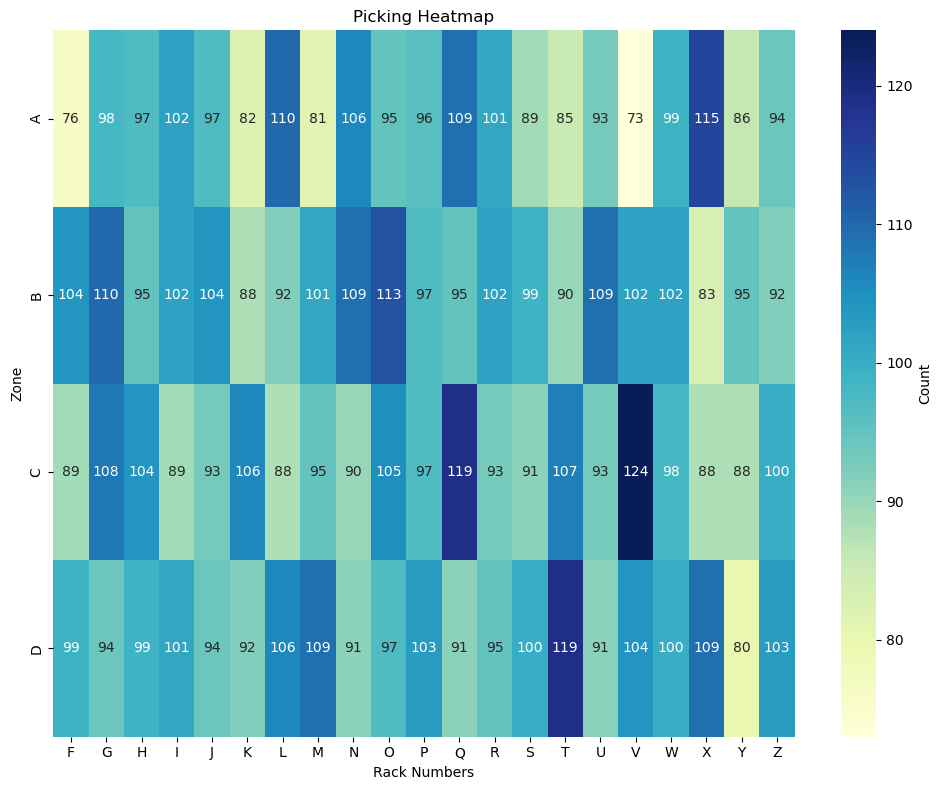

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_m = pd.read_csv('/kaggle/input/mega-star-distribution-centre/picking_1.csv', low_memory=False)
df_m.info()

df_m[['Zone', 'Rack_numbers', 'Location_numbers', 'Levels']] = df_m['Location'].str.extract(r'([A-Z])([A-Z])(\d{2})([A-H])')

df_m.drop('Location', axis=1, inplace=True)

df_m = df_m[['Product', 'Description', 'Pallet', 'Task', 'Staff', 'Quantity', 'Zone', 'Rack_numbers', 'Location_numbers', 'Levels']]

df_m.to_csv('/kaggle/working/split_picking_1.csv', index=False)

print("The split_picking_1.csv has been saved")

df = pd.read_csv('/kaggle/working/split_picking_1.csv')

rack_locations_df = pd.read_csv('/kaggle/input/mega-star-distribution-centre/dc_locations.csv')

rack_locations_df[['Zone', 'Rack_numbers', 'Location_numbers', 'Levels']] = rack_locations_df['Location'].str.extract(r'([A-Z])([A-Z])(\d{2})([A-H])')

rack_locations_df['Location_numbers'] = rack_locations_df['Location_numbers'].astype(str)
df['Location_numbers'] = df['Location_numbers'].astype(str)

rack_stock = rack_locations_df.merge(df, how='left', on=['Zone', 'Rack_numbers', 'Location_numbers', 'Levels'])

grouped_stock = rack_stock.groupby(['Zone', 'Rack_numbers']).agg({'Product': lambda x: x.notnull().sum()}).reset_index()

heatmap_data = grouped_stock.pivot(index='Zone', columns='Rack_numbers', values='Product')

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='.0f', cbar_kws={'label': 'Count'})
plt.title('Picking Heatmap')
plt.xlabel('Rack Numbers')
plt.ylabel('Zone')
plt.tight_layout()
plt.show()

The second section explores the performance of the staff in the picking process. By grouping the data by staff, the number of unique locations visited by each staff member is calculated and visualized using a bar chart. This chart allows us to identify the most active staff members in terms of the number of lines they picked during the period.

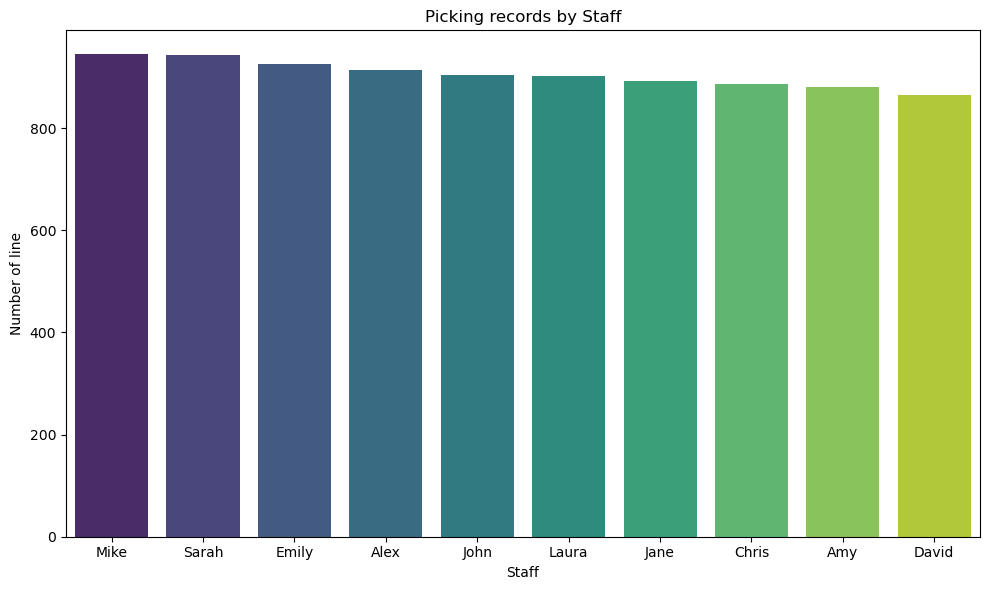

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/mega-star-distribution-centre/picking_1.csv')

pallets_moved_by_staff = df.groupby('Staff')['Location'].nunique().reset_index()

pallets_moved_by_staff = pallets_moved_by_staff.sort_values(by='Location', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Staff', y='Location', data=pallets_moved_by_staff, palette='viridis')
plt.xlabel('Staff')
plt.ylabel('Number of line')
plt.title('Picking records by Staff')
plt.tight_layout()
plt.show()


The third section examines the daily picking records by staff. The data from multiple CSV files is combined to create a comprehensive dataset. Using a line plot, we visualize how the number of lines picked by each staff member evolves over the five days. This chart helps us identify any patterns or trends in the staff's productivity during the observation period.

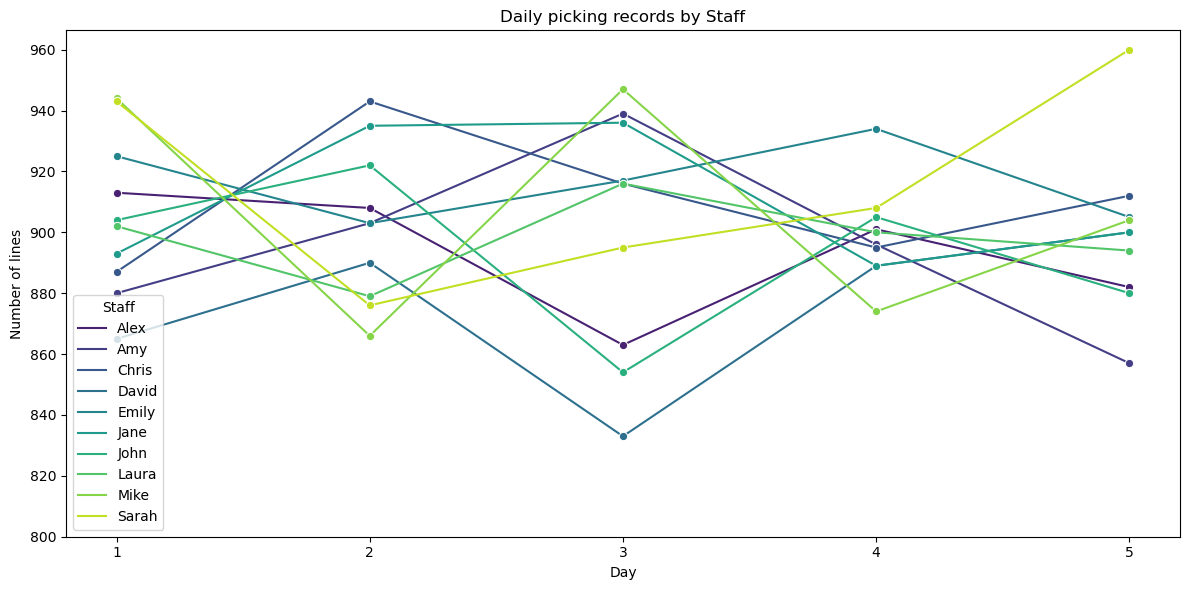

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

file_names = ['/kaggle/input/mega-star-distribution-centre/picking_1.csv', '/kaggle/input/mega-star-distribution-centre/picking_2.csv', '/kaggle/input/mega-star-distribution-centre/picking_3.csv', '/kaggle/input/mega-star-distribution-centre/picking_4.csv', '/kaggle/input/mega-star-distribution-centre/picking_5.csv']

all_data = pd.DataFrame()

for file_name in file_names:
    df = pd.read_csv(file_name)
    day = re.search(r'picking_(\d)\.csv', file_name).group(1)
    df['Day'] = day
    all_data = pd.concat([all_data, df])

pallets_moved_by_staff_and_day = all_data.groupby(['Staff', 'Day'])['Location'].nunique().reset_index()

pallets_moved_by_staff_and_day = pallets_moved_by_staff_and_day.sort_values(by=['Staff', 'Day'])

plt.figure(figsize=(12, 6))
sns.lineplot(x='Day', y='Location', hue='Staff', data=pallets_moved_by_staff_and_day, palette='viridis', marker='o')
plt.xlabel('Day')
plt.ylabel('Number of lines')
plt.title('Daily picking records by Staff')

plt.ylim(bottom=800)

plt.tight_layout()
plt.show()


The fourth section shifts the focus to the put-away (receiving) process. Similar to the previous sections, the data is loaded from 'receiving_1.csv', and the staff performance is visualized using a bar chart. This chart highlights the staff members who have been most active in handling put-away tasks based on the number of lines they processed.

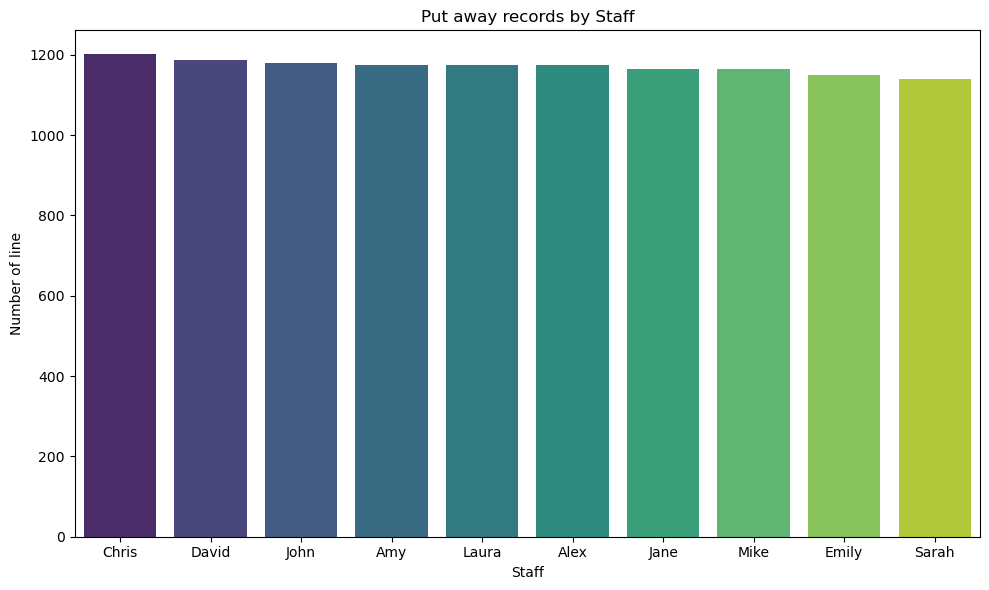

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/mega-star-distribution-centre/receiving_1.csv')

pallets_moved_by_staff = df.groupby('Staff')['Location'].nunique().reset_index()

pallets_moved_by_staff = pallets_moved_by_staff.sort_values(by='Location', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Staff', y='Location', data=pallets_moved_by_staff, palette='viridis')
plt.xlabel('Staff')
plt.ylabel('Number of line')
plt.title('Put away records by Staff')
plt.tight_layout()
plt.show()


The fifth section analyzes the daily receiving records by staff. The data from various receiving files is combined, and a line plot is used to visualize the evolution of receiving tasks over the five days. This chart provides insights into the daily performance of staff in the put-away process.

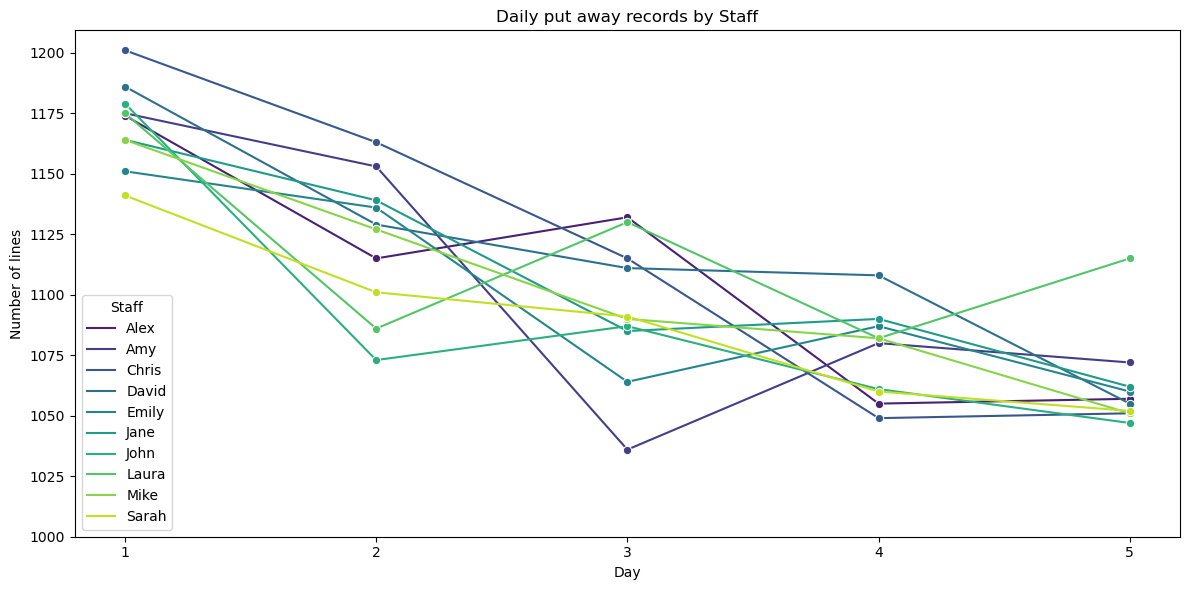

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

file_names = ['/kaggle/input/mega-star-distribution-centre/receiving_1.csv', '/kaggle/input/mega-star-distribution-centre/receiving_2.csv', '/kaggle/input/mega-star-distribution-centre/receiving_3.csv', '/kaggle/input/mega-star-distribution-centre/receiving_4.csv', '/kaggle/input/mega-star-distribution-centre/receiving_5.csv']

all_data = pd.DataFrame()

for file_name in file_names:
    df = pd.read_csv(file_name)
    day = re.search(r'receiving_(\d)\.csv', file_name).group(1)
    df['Day'] = day
    all_data = pd.concat([all_data, df])

pallets_moved_by_staff_and_day = all_data.groupby(['Staff', 'Day'])['Location'].nunique().reset_index()

pallets_moved_by_staff_and_day = pallets_moved_by_staff_and_day.sort_values(by=['Staff', 'Day'])

plt.figure(figsize=(12, 6))
sns.lineplot(x='Day', y='Location', hue='Staff', data=pallets_moved_by_staff_and_day, palette='viridis', marker='o')
plt.xlabel('Day')
plt.ylabel('Number of lines')
plt.title('Daily put away records by Staff')

plt.ylim(bottom=1000)

plt.tight_layout()
plt.show()


The sixth section delves into the top 10 trending products during the five days of picking. The data is processed to calculate the number of pallets picked for each product. A line plot is then used to visualize the trends in pallet movement for the top 10 products over the observation period. This visualization helps identify the products that have been in high demand during this time.

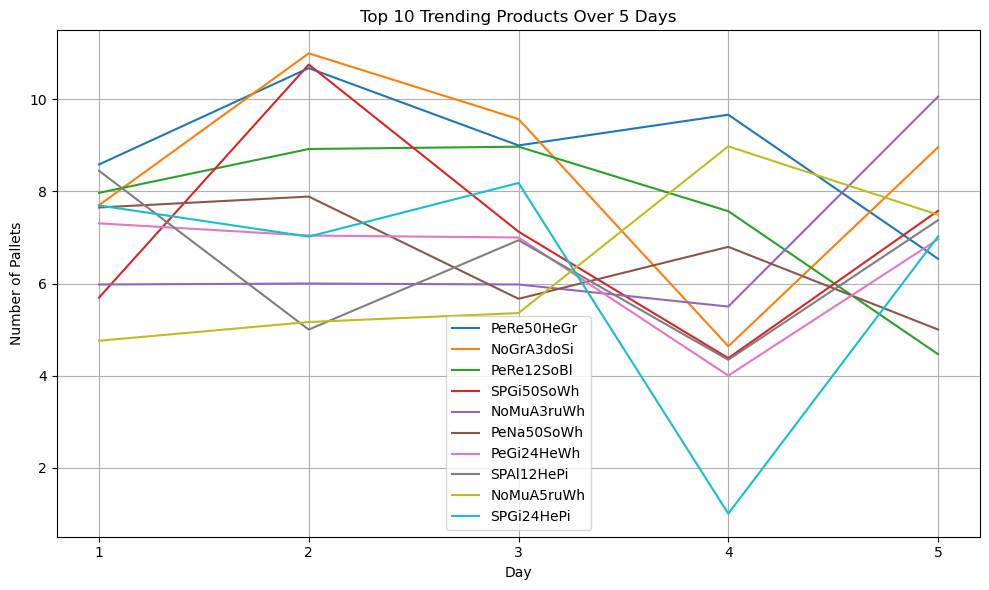

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

file_names = ['/kaggle/input/mega-star-distribution-centre/picking_1.csv', '/kaggle/input/mega-star-distribution-centre/picking_2.csv', '/kaggle/input/mega-star-distribution-centre/picking_3.csv', '/kaggle/input/mega-star-distribution-centre/picking_4.csv', '/kaggle/input/mega-star-distribution-centre/picking_5.csv']

all_data = pd.DataFrame()

for file_name in file_names:
    df = pd.read_csv(file_name)
    day = re.search(r'picking_(\d)\.csv', file_name).group(1)
    df['Day'] = day
    all_data = pd.concat([all_data, df])

def extract_count(packsize):
    parts = packsize.split('*')
    count = np.prod([int(part) for part in parts])
    return count

all_data['Pallets_Picked'] = all_data['Quantity'] / all_data['Pallet'].apply(extract_count)

grouped_data = all_data.groupby(['Product', 'Day']).agg({'Quantity': 'sum', 'Pallets_Picked': 'sum'}).reset_index()

top_10_products = grouped_data.groupby('Product')['Quantity'].sum().nlargest(10).index

top_10_data = grouped_data[grouped_data['Product'].isin(top_10_products)]

plt.figure(figsize=(10, 6))
for product in top_10_products:
    product_data = top_10_data[top_10_data['Product'] == product]
    plt.plot(product_data['Day'], product_data['Pallets_Picked'], label=product)

plt.xlabel('Day')
plt.ylabel('Number of Pallets')
plt.title('Top 10 Trending Products Over 5 Days')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


The seventh section delves into the variance analysis for the top 10 trending products in both the picking and receiving processes. We will calculate the variance between the number of pallets received and picked for each product over the five-day period. This will help us understand any discrepancies or imbalances in the handling of these products.

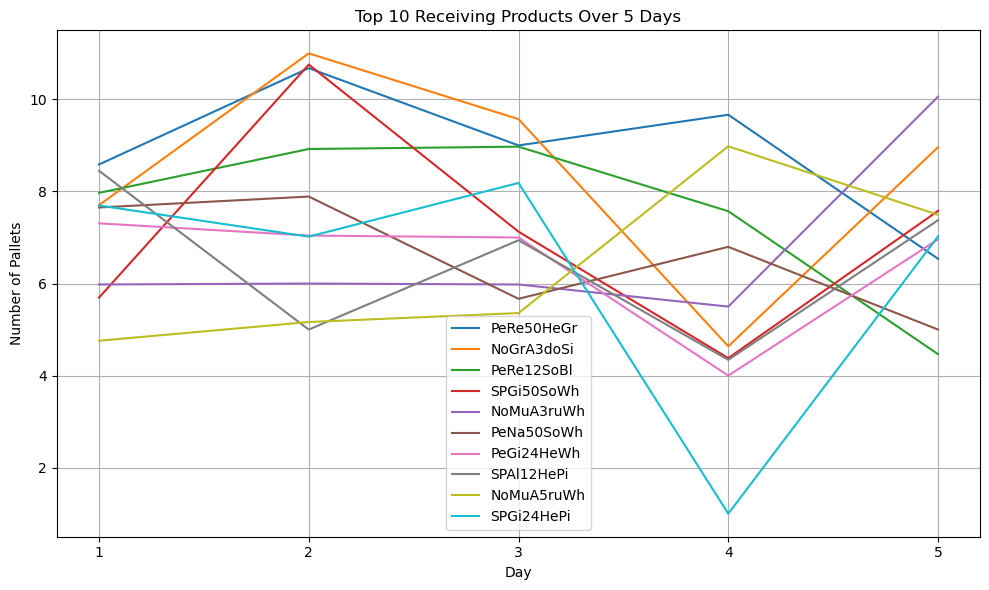

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

file_names = ['/kaggle/input/mega-star-distribution-centre/receiving_1.csv', '/kaggle/input/mega-star-distribution-centre/receiving_2.csv', '/kaggle/input/mega-star-distribution-centre/receiving_3.csv', '/kaggle/input/mega-star-distribution-centre/receiving_4.csv', '/kaggle/input/mega-star-distribution-centre/receiving_5.csv']

all_data = pd.DataFrame()

for file_name in file_names:
    df = pd.read_csv(file_name)
    day = re.search(r'receiving_(\d)\.csv', file_name).group(1)
    df['Day'] = day
    all_data = pd.concat([all_data, df])

def extract_count_receiving(packsize):
    parts = packsize.split('*')
    count = np.prod([int(part) for part in parts])
    return count

all_data['Pallets_Picked'] = all_data['Quantity'] / all_data['Pallet'].apply(extract_count_receiving)

top_10_products = grouped_data.groupby('Product')['Quantity'].sum().nlargest(10).index

top_10_data = grouped_data[grouped_data['Product'].isin(top_10_products)]

plt.figure(figsize=(10, 6))
for product in top_10_products:
    product_data = top_10_data[top_10_data['Product'] == product]
    plt.plot(product_data['Day'], product_data['Pallets_Picked'], label=product)

plt.xlabel('Day')
plt.ylabel('Number of Pallets')
plt.title('Top 10 Receiving Products Over 5 Days')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Finally, the eighth section brings together the insights from both the picking and receiving processes. The variance between the number of pallets received and picked for the top 10 products is calculated and visualized using a line plot. This chart helps identify any discrepancies between the two processes for the most trending products.

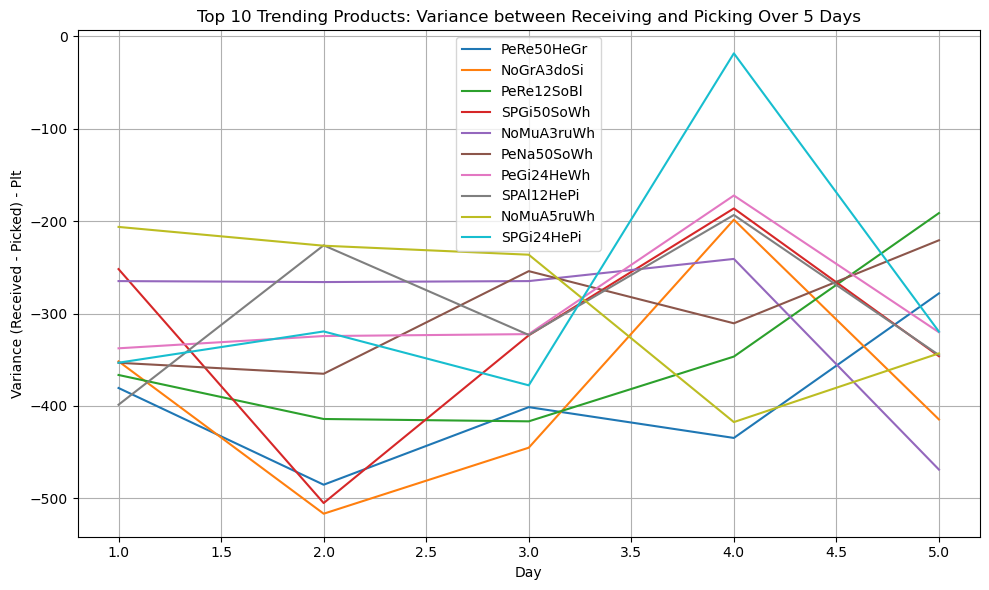

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import re

file_names = ['/kaggle/input/mega-star-distribution-centre/picking_1.csv', '/kaggle/input/mega-star-distribution-centre/picking_2.csv', '/kaggle/input/mega-star-distribution-centre/picking_3.csv', '/kaggle/input/mega-star-distribution-centre/picking_4.csv', '/kaggle/input/mega-star-distribution-centre/picking_5.csv']

all_data = pd.DataFrame()

for file_name in file_names:
    df = pd.read_csv(file_name)
    day = re.search(r'picking_(\d)\.csv', file_name).group(1)
    df['Day'] = int(day)
    all_data = pd.concat([all_data, df])

def extract_count(packsize):
    parts = packsize.split('*')
    count = int(parts[0])
    return count

all_data['Pallets_Picked'] = all_data['Quantity'] / all_data['Pallet'].apply(extract_count)

grouped_data = all_data.groupby(['Product', 'Day']).agg({'Quantity': 'sum', 'Pallets_Picked': 'sum'}).reset_index()

top_10_products = grouped_data.groupby('Product')['Quantity'].sum().nlargest(10).index

top_10_data = grouped_data[grouped_data['Product'].isin(top_10_products)]

receiving_file_names = ['/kaggle/input/mega-star-distribution-centre/receiving_1.csv', '/kaggle/input/mega-star-distribution-centre/receiving_2.csv', '/kaggle/input/mega-star-distribution-centre/receiving_3.csv', '/kaggle/input/mega-star-distribution-centre/receiving_4.csv', '/kaggle/input/mega-star-distribution-centre/receiving_5.csv']

receiving_dfs = [pd.read_csv(file) for file in receiving_file_names]

receiving_df = pd.concat(receiving_dfs, ignore_index=True)

def extract_count_receiving(packsize):
    parts = packsize.split('*')
    count = np.prod([int(part) for part in parts])
    return count

receiving_df['Pallets_Received'] = receiving_df['Quantity'] / receiving_df['Pallet'].apply(extract_count_receiving)

receiving_top_10_data = receiving_df[receiving_df['Product'].isin(top_10_products)]

receiving_grouped_data = receiving_top_10_data.groupby('Product').agg({'Quantity': 'sum', 'Pallets_Received': 'sum'}).reset_index()

top_10_with_receiving = pd.merge(top_10_data, receiving_grouped_data, on='Product', how='left')

top_10_with_receiving['Variance'] = top_10_with_receiving['Pallets_Received'] - top_10_with_receiving['Pallets_Picked']

plt.figure(figsize=(10, 6))
for product in top_10_products:
    product_data = top_10_with_receiving[top_10_with_receiving['Product'] == product]
    plt.plot(product_data['Day'], product_data['Variance'], label=product)

plt.xlabel('Day')
plt.ylabel('Variance (Received - Picked) - Plt')
plt.title('Top 10 Trending Products: Variance between Receiving and Picking Over 5 Days')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 4. Conclusion

The analysis of the Mega Star Distribution Centre dataset has provided valuable insights into the world of logistics and warehousing. As we explored the dataset, several key takeaways emerged:

   1. Python as a Powerful Tool: Throughout this analysis, Python has proven to be a versatile and powerful tool for handling vast datasets. From data cleaning and transformation to advanced analytics and visualization, Python's extensive libraries, such as Pandas, Seaborn, and Matplotlib, have enabled us to process and analyze data efficiently.

   2. AI for Problem Solving: The integration of artificial intelligence (AI) tools can greatly benefit logistics and warehousing operations. AI algorithms can quickly process large amounts of data, identify patterns, and make data-driven decisions. Implementing AI-driven solutions can lead to optimized inventory management, better demand forecasting, and more effective route planning.

   3. Data-Driven Decision-Making: In the age of technology, data-driven decision-making is paramount. Analyzing warehouse data allows us to uncover valuable insights, identify bottlenecks, and make informed choices to optimize processes. Utilizing data analytics empowers companies to stay ahead of competitors and deliver better customer experiences.

   4. Continuous Improvement: The world of logistics and warehousing is constantly evolving. It is crucial for companies to embrace a culture of continuous improvement. By leveraging the power of data, automation, and AI-driven tools, businesses can stay agile and adapt to changing market demands effectively.
   
   5. Embracing Automation: Logistics and warehousing are witnessing rapid advancements in automation. Automated systems, such as robotics and intelligent machines, are revolutionizing the way we manage inventory, handle shipments, and optimize storage space. By adopting automation, companies can enhance efficiency, reduce manual errors, and streamline operations.